# **Implementación de los casos de 3 Qubits**

In [2]:
%load_ext autoreload
%autoreload 2

import modules
from modules.Schnorr_QAOA import SchnorrAlgQAOA


import numpy as np
import matplotlib.pyplot as plt
from qiskit.visualization import plot_histogram


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
seed = 99

In [4]:
N3 = 1961

In [5]:
threeQubit = SchnorrAlgQAOA(N3, 1.5, 1, seed)

El numero de bits de N = 1961 es m = 11
La dimension del reticulo que vamos a tratar es n = 3
La cota smooth que vamos a tomar: 9


In [6]:
B3, t3 = threeQubit.generate_cvp(10)
print(f'B3 = \n{B3}')
print(f't3 = \n{t3}')

B3 = 
[ 1 0 0 22 ]
[ 0 2 0 35 ]
[ 0 0 1 51 ]
t3 = 
(0, 0, 0, 240)


In [7]:
D3 = threeQubit.lll_reduced(B3, delta = 0.75)
print(f'D3 = \n{D3}')

D3 = 
[  3 2 -2 -1 ]
[ -4 2  1 -2 ]
[ -3 4  0  4 ]


In [8]:
D3, b3_op, res3_vector, sign_step3, w3, dist3 = threeQubit.babai_algorithm(B3, t3, delta = 0.75)
print(f'D3 = \n{D3}\n')
print(f'b3_op = \n{b3_op}\n')
print(f'res3_vector = \n{res3_vector}\n')
print(f'sign_step3 = \n{sign_step3}\n')
print(f'w3 = \n{w3}\n')
print(f'dist3 = \n{dist3}\n')

D3 = 
[  3 2 -2 -1 ]
[ -4 2  1 -2 ]
[ -3 4  0  4 ]

b3_op = 
[  0   2   4 239]

res3_vector = 
[ 0 -2 -4  1]

sign_step3 = 
[ 1 -1  1]

w3 = 
(-23, -42, 33)

dist3 = 
4.58257569495584



In [9]:
qubo3 = threeQubit.define_qubo(D3, res3_vector, sign_step3)

print(qubo3.prettyprint())

Problem name: quboProblem

Minimize
  18*z_0^2 + 16*z_0*z_1 - 10*z_0*z_2 + 25*z_1^2 - 24*z_1*z_2 + 41*z_2^2 - 6*z_0
  - 20*z_1 + 8*z_2 + 21

Subject to
  No constraints

  Binary variables (3)
    z_0 z_1 z_2



In [10]:
Hc3, offset3 = threeQubit.define_hamiltonian(qubo3)

print("Offset = {}\n".format(offset3))
print("Hamiltonian = {}".format(Hc3))

Offset = 49.5

Hamiltonian = SparsePauliOp(['IIZ', 'IZI', 'ZII', 'IZZ', 'ZIZ', 'ZZI'],
              coeffs=[ -7.5+0.j,  -0.5+0.j, -16. +0.j,   4. +0.j,  -2.5+0.j,  -6. +0.j])


In [11]:
circuit3 = threeQubit.construct_circuit(Hc3, 1)
print(circuit3.decompose(reps = 1))

     ┌───┐┌─────────────────────────────────────────────────────┐»
q_0: ┤ H ├┤0                                                    ├»
     ├───┤│                                                     │»
q_1: ┤ H ├┤1 exp(-it (IIZ + IZI + ZII + IZZ + ZIZ + ZZI))(γ[0]) ├»
     ├───┤│                                                     │»
q_2: ┤ H ├┤2                                                    ├»
     └───┘└─────────────────────────────────────────────────────┘»
«     ┌───────────────────────────────────┐
«q_0: ┤0                                  ├
«     │                                   │
«q_1: ┤1 exp(-it (XII + IXI + IIX))(β[0]) ├
«     │                                   │
«q_2: ┤2                                  ├
«     └───────────────────────────────────┘


In [12]:
x0 = np.asarray([0.0]*circuit3.num_parameters)

optParameters3 = threeQubit.qaoa_algorithm(circuit3, Hc3, x0)

/home/zheng/tfg/TFG_GII/.venv/lib/python3.12/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/home/zheng/tfg/TFG_GII/.venv/lib/python3.12/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


In [13]:
print(optParameters3)

{ParameterVectorElement(β[0]): np.float64(-0.651417868648273), ParameterVectorElement(γ[0]): np.float64(0.04646030232474015)}


In [14]:
ncircuit3 = threeQubit.circ_asign_params(circuit3, optParameters3)
print(ncircuit3.decompose(reps=2))

     ┌────────────┐┌─────────────┐                             ┌─────────────┐»
q_0: ┤ U(π/2,0,π) ├┤ Rz(-0.6969) ├──■─────────────■────────────┤ Rx(-1.3028) ├»
     ├────────────┤├─────────────┴┐ │ZZ(0.37168)  │            └─────────────┘»
q_1: ┤ U(π/2,0,π) ├┤ Rz(-0.04646) ├─■─────────────┼─────────────■─────────────»
     ├────────────┤├─────────────┬┘               │ZZ(-0.2323)  │ZZ(-0.55752) »
q_2: ┤ U(π/2,0,π) ├┤ Rz(-1.4867) ├────────────────■─────────────■─────────────»
     └────────────┘└─────────────┘                                            »
«                    
«q_0: ───────────────
«     ┌─────────────┐
«q_1: ┤ Rx(-1.3028) ├
«     ├─────────────┤
«q_2: ┤ Rx(-1.3028) ├
«     └─────────────┘


In [15]:
results3 = threeQubit.sample_from_parameters(circuit3, optParameters3, shots = 10_000)
print(len(results3))
for bitstring, count in results3.items():
    print(f"Bistring: {bitstring} -> Counts: {count}")

8
Bistring: 000 -> Counts: 3689
Bistring: 010 -> Counts: 3471
Bistring: 001 -> Counts: 1234
Bistring: 011 -> Counts: 597
Bistring: 110 -> Counts: 483
Bistring: 111 -> Counts: 334
Bistring: 100 -> Counts: 155
Bistring: 101 -> Counts: 37


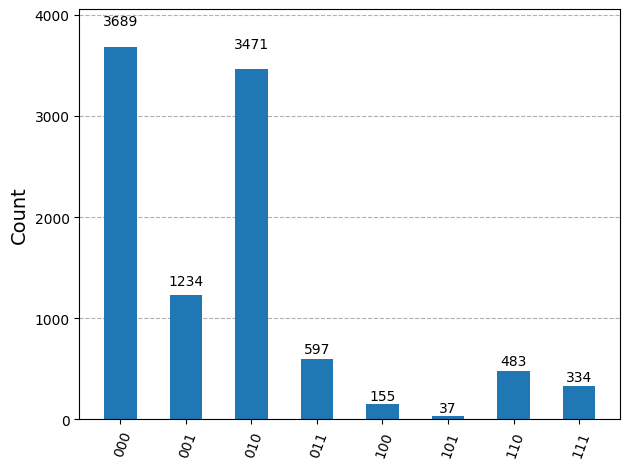

In [16]:
plot_histogram(results3)

In [17]:
nD3 = threeQubit.integer_to_matrix(D3)
print(nD3)

[[ 3  2 -2 -1]
 [-4  2  1 -2]
 [-3  4  0  4]]


In [18]:
vnew3 = threeQubit.bitstring2latticeVectors(nD3, results3.keys(), sign_step3, b3_op)
print(vnew3)

[[  0   2   4 239]
 [  4   0   3 241]
 [ -3   6   4 243]
 [  1   4   3 245]
 [  7   2   1 240]
 [  4   6   1 244]
 [  3   4   2 238]
 [  0   8   2 242]]


In [19]:
distances3 = threeQubit.get_distances(vnew3, t3)
for dist3 in distances3:
    print(np.linalg.norm(dist3))

4.58257569495584
5.0990195135927845
8.366600265340756
7.14142842854285
7.3484692283495345
8.306623862918075
5.744562646538029
8.48528137423857


In [20]:
nB3 = threeQubit.integer_to_matrix(B3)
print(nB3)

[[ 1  0  0 22]
 [ 0  2  0 35]
 [ 0  0  1 51]]


In [21]:
uv_pairs3 = threeQubit.vectors2uv_pairs(nB3, vnew3)
print(uv_pairs3)

[[1875 1]
 [2000 1]
 [16875 8]
 [2250 1]
 [1920 1]
 [2160 1]
 [1800 1]
 [2025 1]]


In [22]:
sr_pairs3 = threeQubit.uv_pairs2sr_pairs(uv_pairs3)
print(sr_pairs3)

[(2000, 1), (2250, 1), (1800, 1), (2025, 1)]


In [23]:
probs3 = threeQubit.get_probs(results3, shots = 10_000)

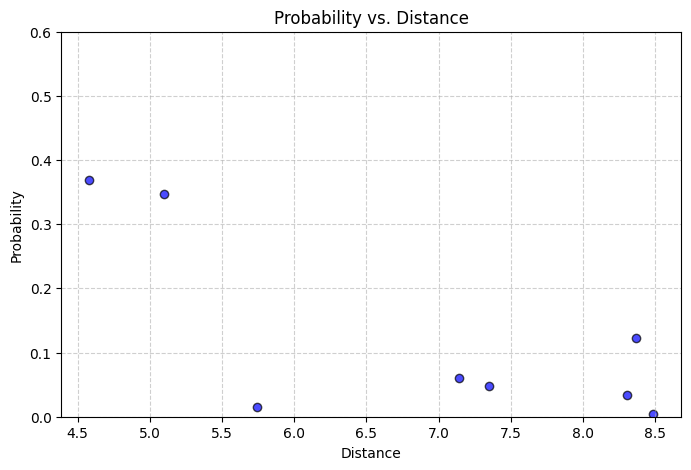

In [24]:
plt.figure(figsize=(8, 5))

# Creating the scatter plot
plt.scatter(distances3, probs3, color='blue', edgecolors='black', alpha=0.7)

# Adding labels and title
plt.xlabel('Distance')
plt.ylabel('Probability')
plt.title('Probability vs. Distance')

# Setting y-axis limit since you mentioned probs are <= 0.2
plt.ylim(0, 0.60) 

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()